In [1]:
# === FULL PIPELINE: Advanced Upgrades ===
import pandas as pd
import numpy as np
import torch
from torch.nn.utils.rnn import pad_sequence
from sklearn.preprocessing import MinMaxScaler
from sentence_transformers import SentenceTransformer

# === Load CSVs ===
sentiment_df = pd.read_csv("sentiment_replies.csv")
topic_df = pd.read_csv("topic.csv")

# === Clean sentiment_replies.csv ===
sentiment_df['dateTime'] = (
    sentiment_df['dateTime'].astype(str).str.replace('»', '', regex=False).str.strip()
)
sentiment_df['dateTime'] = pd.to_datetime(sentiment_df['dateTime'], format='mixed')

sentiment_df['postcount'] = (
    sentiment_df['postcount'].astype(str)
    .str.extract(r'(\d[\d,]*)')[0]
    .str.replace(',', '', regex=False)
    .astype(float)
)

sentiment_df['author'] = sentiment_df['author'].astype(str).str.strip().str.lower()
sentiment_df['member group'] = sentiment_df['member group'].astype(str).str.strip().str.lower()

sentiment_df['reply_index'] = (
    sentiment_df['threadDetails'].astype(str)
    .str.extract(r'Reply\s+#(\d+)', expand=False)
    .fillna(0).astype(int)
)

sentiment_columns = ['pos', 'neg', 'neu', 'compound', 'textblob_sentiment']
for col in sentiment_columns:
    sentiment_df[col] = pd.to_numeric(sentiment_df[col], errors='coerce')

sentiment_df_cleaned = sentiment_df.dropna(subset=['dateTime', 'postId'])
sentiment_df_cleaned = sentiment_df_cleaned.drop_duplicates(subset=['postId'])
sentiment_df_cleaned.reset_index(drop=True, inplace=True)

# === Clean topic.csv ===
topic_df['views'] = (
    topic_df['views'].astype(str)
    .str.replace(r'\s+', '', regex=True)
    .str.replace(r'\D', '', regex=True)
    .replace('', np.nan)
    .astype(float)
)

topic_df['datePost'] = (
    topic_df['datePost'].astype(str)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)
topic_df['datePost'] = pd.to_datetime(topic_df['datePost'], format='mixed')

topic_df['replies'] = pd.to_numeric(topic_df['replies'], errors='coerce').fillna(0).astype(int)

for col in ['topic', 'startedBy', 'latestBy']:
    topic_df[col] = topic_df[col].astype(str).str.strip().str.lower().replace('nan', 'unknown')

topic_df_cleaned = topic_df.dropna(subset=['id', 'datePost']).drop_duplicates(subset=['id']).reset_index(drop=True)

# === Merge ===
merged_df = sentiment_df_cleaned.merge(
    topic_df_cleaned, left_on="connecting_id", right_on="id",
    suffixes=('_reply', '_topic')
)
merged_df = merged_df.sort_values(by=["connecting_id", "dateTime"]).reset_index(drop=True)
merged_df['delta_t'] = merged_df.groupby('connecting_id')['dateTime'].diff().dt.total_seconds() / 3600
merged_df['delta_t'] = merged_df['delta_t'].fillna(0)

# === Create enriched feature_df ===
feature_df = merged_df[[
    'connecting_id', 'postId', 'dateTime', 'replyMess', 'delta_t',
    'compound', 'textblob_sentiment', 'reply_index',
    'postcount', 'views', 'replies', 'topic', 'author', 'startedBy'
]].copy()

# Label: will there be a reply within 24h?
feature_df['label'] = 0
grouped = feature_df.groupby("connecting_id")
for thread_id, group in grouped:
    times = group['dateTime'].values
    indices = group.index.values
    for i in range(len(times) - 1):
        current_time = times[i]
        future_times = times[i+1:]
        time_gaps = (future_times - current_time) / np.timedelta64(1, 'h')
        if any(time_gaps <= 24):
            feature_df.loc[indices[i], 'label'] = 1

# === λ(t): time until next reply ===
feature_df = feature_df.sort_values(by=["connecting_id", "dateTime"]).reset_index(drop=True)
feature_df['lambda_target'] = (
    feature_df.groupby('connecting_id')['dateTime']
    .transform(lambda x: x.shift(-1) - x)
    .dt.total_seconds() / 3600
)
feature_df['lambda_target'] = np.log1p(feature_df['lambda_target'])  # log transform

# === count(t): replies in next 24h as bucket ===
def bucketize_count(c):
    if c == 0: return 0
    elif c == 1: return 1
    elif c == 2: return 2
    else: return 3

def count_within_24h(group):
    times = group['dateTime'].tolist()
    return pd.Series([
        sum((t < t2 <= t + pd.Timedelta(hours=24)) for t2 in times[i+1:])
        for i, t in enumerate(times)
    ], index=group.index)

feature_df['count_target'] = feature_df.groupby('connecting_id').apply(count_within_24h).reset_index(level=0, drop=True)
feature_df['count_bucket'] = feature_df['count_target'].apply(bucketize_count)

# === Positional + temporal features ===
feature_df['step_index'] = feature_df.groupby('connecting_id').cumcount()
feature_df['hour'] = feature_df['dateTime'].dt.hour / 23.0
feature_df['weekday'] = feature_df['dateTime'].dt.weekday / 6.0
feature_df['is_thread_starter'] = (feature_df['author'] == feature_df['startedBy']).astype(int)

# === SBERT Embedding ===
sbert = SentenceTransformer('all-MiniLM-L6-v2')
reply_texts = feature_df['replyMess'].astype(str).tolist()
reply_embeddings = sbert.encode(reply_texts, show_progress_bar=True)

# === Normalize and Combine Features ===
scaler = MinMaxScaler()
feature_cols = [
    'delta_t', 'compound', 'textblob_sentiment', 'reply_index',
    'postcount', 'views', 'replies', 'step_index', 'hour', 'weekday', 'is_thread_starter'
]
feature_df[feature_cols] = scaler.fit_transform(feature_df[feature_cols])
X_structured = feature_df[feature_cols].values
X_combined = np.hstack((X_structured, reply_embeddings))

print("✅ Final feature shape per post:", X_combined.shape[1])


C:\Users\shubb\AppData\Local\Temp\ipykernel_14492\2021412656.py:118: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  feature_df['count_target'] = feature_df.groupby('connecting_id').apply(count_within_24h).reset_index(level=0, drop=True)


Batches:   0%|          | 0/217 [00:00<?, ?it/s]

✅ Final feature shape per post: 395


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from sklearn.metrics import precision_recall_fscore_support, mean_absolute_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd

class DecayedAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.u = nn.Parameter(torch.randn(hidden_dim))
        self.w = nn.Parameter(torch.tensor(1.0))

    def forward(self, h, times, mask=None):
        B, T, H = h.shape
        time_diffs = times.unsqueeze(2) - times.unsqueeze(1)
        gamma = torch.exp(-self.w * time_diffs.clamp(min=0))
        u_proj = torch.tanh(torch.matmul(h, self.u))
        e = u_proj.unsqueeze(2) * gamma
        if mask is not None:
            mask = mask.unsqueeze(1).expand(B, T, T)
            e = e.masked_fill(~mask, float('-inf'))
        attn_weights = F.softmax(e, dim=2)
        context = torch.bmm(attn_weights, h)
        return context, attn_weights

class BehavioralPointProcessModel(nn.Module):
    def __init__(self, input_dim=395, hidden_dim=128, count_classes=4):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.attn_time = DecayedAttention(hidden_dim)
        self.attn_reply = DecayedAttention(hidden_dim)
        self.attn_count = DecayedAttention(hidden_dim)
        self.time_head = nn.Sequential(nn.Linear(hidden_dim, 1), nn.Softplus())
        self.reply_head = nn.Sequential(nn.Linear(hidden_dim, 1), nn.Sigmoid())
        self.count_head = nn.Linear(hidden_dim, count_classes)  # classification

    def forward(self, x, times, mask):
        h, _ = self.gru(x)
        s_time, attn_time = self.attn_time(h, times, mask)
        s_reply, attn_reply = self.attn_reply(h, times, mask)
        s_count, attn_count = self.attn_count(h, times, mask)
        lambda_t = self.time_head(s_time).squeeze(-1)
        pi_reply = self.reply_head(s_reply).squeeze(-1)
        count_logits = self.count_head(s_count)  # shape: (B, T, num_classes)
        return {
            'lambda': lambda_t,
            'reply_prob': pi_reply,
            'count_logits': count_logits,
            'attn_time': attn_time,
            'attn_reply': attn_reply,
            'attn_count': attn_count
        }

def train_multitask(model, X_train, y_reply, y_lambda, y_count_class, t_train, X_val, y_reply_val, y_lambda_val, y_count_class_val, t_val, num_epochs=20, lr=1e-3, patience=3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    mask_train = (X_train.sum(dim=-1) != 0)
    mask_val = (X_val.sum(dim=-1) != 0)

    X_train, y_reply, y_lambda, y_count_class, t_train, mask_train = [t.to(device) for t in [X_train, y_reply, y_lambda, y_count_class, t_train, mask_train]]
    X_val, y_reply_val, y_lambda_val, y_count_class_val, t_val, mask_val = [t.to(device) for t in [X_val, y_reply_val, y_lambda_val, y_count_class_val, t_val, mask_val]]

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5, verbose=True)
    bce_loss = nn.BCELoss(reduction='none')
    mse_loss = nn.MSELoss(reduction='none')
    ce_loss = nn.CrossEntropyLoss(reduction='none')

    best_loss = float('inf')
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        output = model(X_train, t_train, mask_train)
        pred_reply = output['reply_prob']
        pred_lambda = output['lambda']
        pred_count_logits = output['count_logits']

        loss_reply = (bce_loss(pred_reply, y_reply) * mask_train).sum() / mask_train.sum()
        loss_lambda = (mse_loss(pred_lambda, y_lambda) * mask_train).sum() / mask_train.sum()

        flat_mask = mask_train.view(-1)
        flat_logits = pred_count_logits.view(-1, pred_count_logits.size(-1))
        flat_labels = y_count_class.view(-1)
        loss_count = (ce_loss(flat_logits, flat_labels) * flat_mask).sum() / flat_mask.sum()

        total_loss = 2.0 * loss_reply + 1.0 * loss_lambda + 0.5 * loss_count
        total_loss.backward()
        optimizer.step()
        scheduler.step(total_loss)

        model.eval()
        with torch.no_grad():
            val_output = model(X_val, t_val, mask_val)
            val_pred_reply = val_output['reply_prob']
            val_pred_lambda = val_output['lambda']
            val_pred_count_logits = val_output['count_logits']

            val_loss_reply = (bce_loss(val_pred_reply, y_reply_val) * mask_val).sum() / mask_val.sum()
            val_loss_lambda = (mse_loss(val_pred_lambda, y_lambda_val) * mask_val).sum() / mask_val.sum()

            val_flat_mask = mask_val.view(-1)
            val_flat_logits = val_pred_count_logits.view(-1, val_pred_count_logits.size(-1))
            val_flat_labels = y_count_class_val.view(-1)
            val_loss_count = (ce_loss(val_flat_logits, val_flat_labels) * val_flat_mask).sum() / val_flat_mask.sum()

            val_total_loss = 2.0 * val_loss_reply + 1.0 * val_loss_lambda + 0.5 * val_loss_count

            pred_labels = (val_pred_reply > 0.5).float()
            flat_preds = pred_labels[mask_val].cpu().numpy()
            flat_true = y_reply_val[mask_val].cpu().numpy()
            precision, recall, f1, _ = precision_recall_fscore_support(flat_true, flat_preds, average='binary', zero_division=0)

            mae_lambda = mean_absolute_error(y_lambda_val[mask_val].cpu(), val_pred_lambda[mask_val].cpu())

        print(f"Epoch {epoch+1}: Total Loss = {val_total_loss.item():.4f}")
        print(f"  Reply → Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
        print(f"  Lambda → MAE: {mae_lambda:.2f} (log hours)")

        if val_total_loss.item() < best_loss:
            best_loss = val_total_loss.item()
            patience_counter = 0
            torch.save(model.state_dict(), "best_multitask_model.pt")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break


In [3]:
# === Prepare Data for Training with New Targets ===
import numpy as np
import torch
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split

# Prepare targets for padded sequences
sequences = []
reply_labels = []
lambda_targets = []
count_classes = []

# Group and build sequences
for thread_id, group in feature_df.groupby("connecting_id"):
    idx = group.index
    feature_tensor = torch.tensor(X_combined[idx], dtype=torch.float32)
    reply_tensor = torch.tensor(feature_df.loc[idx, 'label'].values, dtype=torch.float32)
    lambda_tensor = torch.tensor(feature_df.loc[idx, 'lambda_target'].fillna(0).values, dtype=torch.float32)
    count_tensor = torch.tensor(feature_df.loc[idx, 'count_bucket'].values, dtype=torch.long)

    sequences.append(feature_tensor)
    reply_labels.append(reply_tensor)
    lambda_targets.append(lambda_tensor)
    count_classes.append(count_tensor)

# Pad all sequences
padded_inputs = pad_sequence(sequences, batch_first=True)
padded_labels = pad_sequence(reply_labels, batch_first=True)
padded_lambda = pad_sequence(lambda_targets, batch_first=True)
padded_count_class = pad_sequence(count_classes, batch_first=True)

# Pad times
time_sequences = []
for _, group in feature_df.groupby("connecting_id"):
    times = torch.tensor(group['delta_t'].values, dtype=torch.float32)
    time_sequences.append(times)
padded_times = pad_sequence(time_sequences, batch_first=True)

# Split into train/val
num_threads = padded_inputs.shape[0]
indices = np.arange(num_threads)
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)

X_train = padded_inputs[train_idx]
y_train = padded_labels[train_idx]
lambda_train = padded_lambda[train_idx]
count_train_class = padded_count_class[train_idx]
t_train = padded_times[train_idx]

X_val = padded_inputs[val_idx]
y_val = padded_labels[val_idx]
lambda_val = padded_lambda[val_idx]
count_val_class = padded_count_class[val_idx]
t_val = padded_times[val_idx]

# === Train Model ===
model = BehavioralPointProcessModel(input_dim=padded_inputs.shape[2])
train_multitask(
    model=model,
    X_train=X_train,
    y_reply=y_train,
    y_lambda=lambda_train,
    y_count_class=count_train_class,
    t_train=t_train,
    X_val=X_val,
    y_reply_val=y_val,
    y_lambda_val=lambda_val,
    y_count_class_val=count_val_class,
    t_val=t_val,
    num_epochs=250, lr=1e-5, patience=15
)


C:\Users\shubb\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1: Total Loss = 7.6060
  Reply → Precision: 0.0000, Recall: 0.0000, F1: 0.0000
  Lambda → MAE: 1.69 (log hours)
Epoch 2: Total Loss = 7.6048
  Reply → Precision: 0.0000, Recall: 0.0000, F1: 0.0000
  Lambda → MAE: 1.69 (log hours)
Epoch 3: Total Loss = 7.6035
  Reply → Precision: 0.0000, Recall: 0.0000, F1: 0.0000
  Lambda → MAE: 1.69 (log hours)
Epoch 4: Total Loss = 7.6023
  Reply → Precision: 0.0000, Recall: 0.0000, F1: 0.0000
  Lambda → MAE: 1.69 (log hours)
Epoch 5: Total Loss = 7.6010
  Reply → Precision: 0.0000, Recall: 0.0000, F1: 0.0000
  Lambda → MAE: 1.69 (log hours)
Epoch 6: Total Loss = 7.5998
  Reply → Precision: 0.0000, Recall: 0.0000, F1: 0.0000
  Lambda → MAE: 1.69 (log hours)
Epoch 7: Total Loss = 7.5985
  Reply → Precision: 0.0000, Recall: 0.0000, F1: 0.0000
  Lambda → MAE: 1.69 (log hours)
Epoch 8: Total Loss = 7.5973
  Reply → Precision: 0.0000, Recall: 0.0000, F1: 0.0000
  Lambda → MAE: 1.69 (log hours)
Epoch 9: Total Loss = 7.5960
  Reply → Precision: 0.0000

C:\Users\shubb\AppData\Local\Temp\ipykernel_14492\386841402.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_multitask_model.pt"))


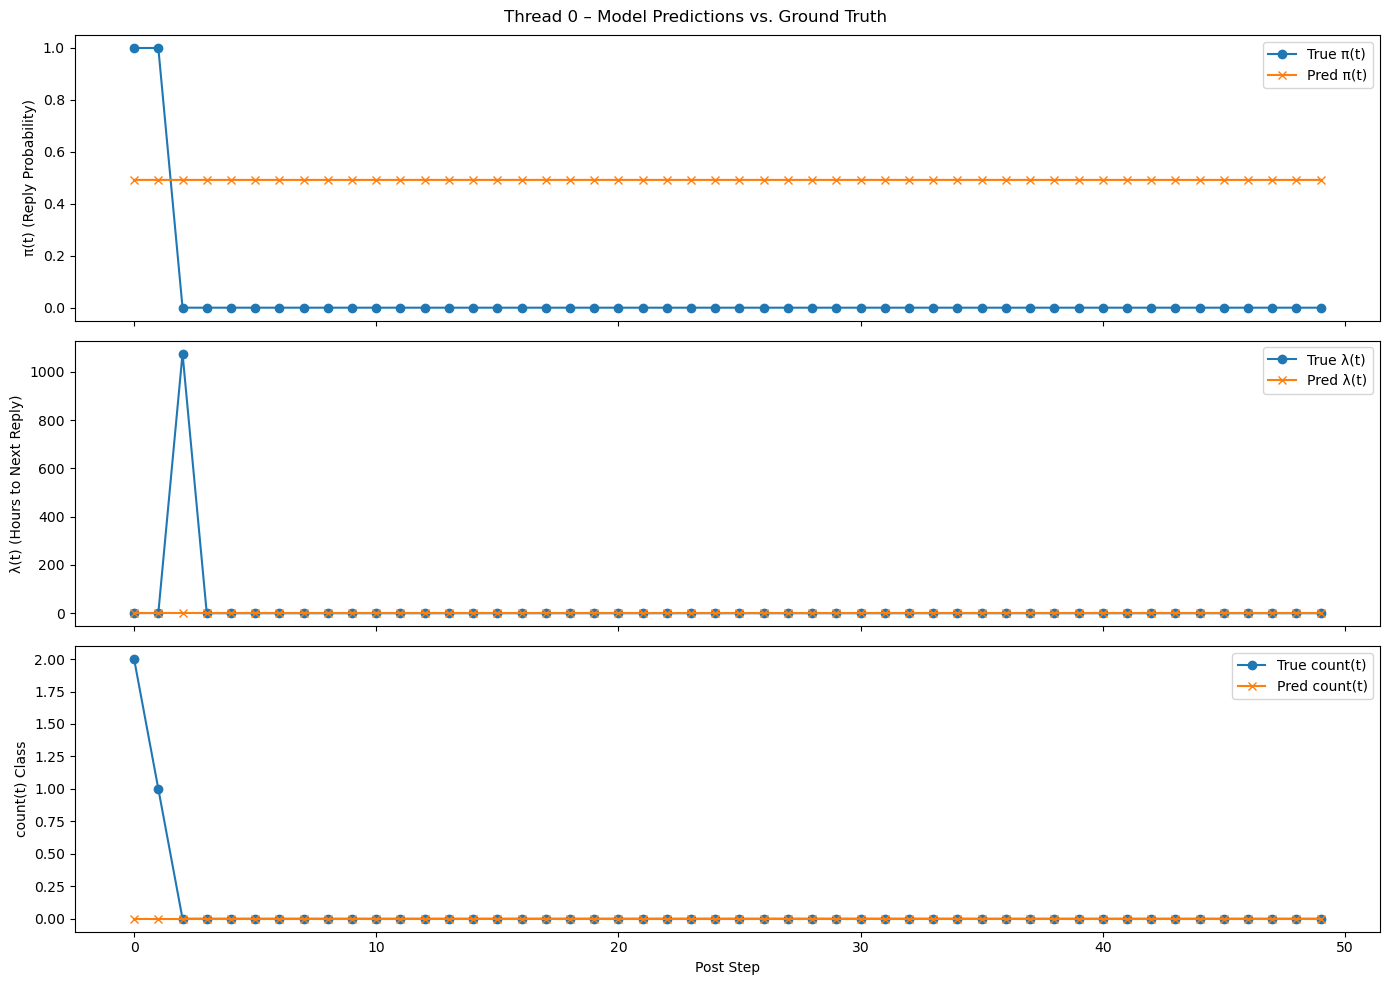

In [4]:
def plot_thread_predictions(thread_id=0):
    import matplotlib.pyplot as plt
    import torch

    model = BehavioralPointProcessModel(input_dim=X_val.shape[2])
    model.load_state_dict(torch.load("best_multitask_model.pt"))
    model.eval()

    with torch.no_grad():
        x = X_val[thread_id].unsqueeze(0)
        t = t_val[thread_id].unsqueeze(0)
        m = (x.sum(-1) != 0)

        output = model(x, t, m)
        pred_reply = output['reply_prob'][0].cpu().numpy()
        pred_lambda = torch.expm1(output['lambda'][0]).cpu().numpy()
        pred_count_class = torch.argmax(output['count_logits'][0], dim=-1).cpu().numpy()

        true_reply = y_val[thread_id].cpu().numpy()
        true_lambda = torch.expm1(lambda_val[thread_id]).cpu().numpy()
        true_count_class = count_val_class[thread_id].cpu().numpy()

    steps = list(range(len(true_reply)))

    fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    axs[0].plot(steps, true_reply, label='True π(t)', marker='o')
    axs[0].plot(steps, pred_reply, label='Pred π(t)', marker='x')
    axs[0].set_ylabel("π(t) (Reply Probability)")
    axs[0].legend()

    axs[1].plot(steps, true_lambda, label='True λ(t)', marker='o')
    axs[1].plot(steps, pred_lambda, label='Pred λ(t)', marker='x')
    axs[1].set_ylabel("λ(t) (Hours to Next Reply)")
    axs[1].legend()

    axs[2].plot(steps, true_count_class, label='True count(t)', marker='o')
    axs[2].plot(steps, pred_count_class, label='Pred count(t)', marker='x')
    axs[2].set_ylabel("count(t) Class")
    axs[2].set_xlabel("Post Step")
    axs[2].legend()

    plt.suptitle(f"Thread {thread_id} – Model Predictions vs. Ground Truth")
    plt.tight_layout()
    plt.show()


plot_thread_predictions(thread_id=0)


C:\Users\shubb\AppData\Local\Temp\ipykernel_14492\936325303.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_multitask_model.pt"))


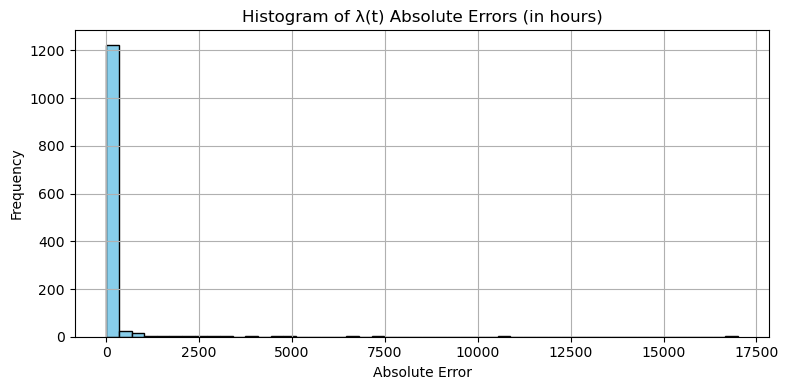

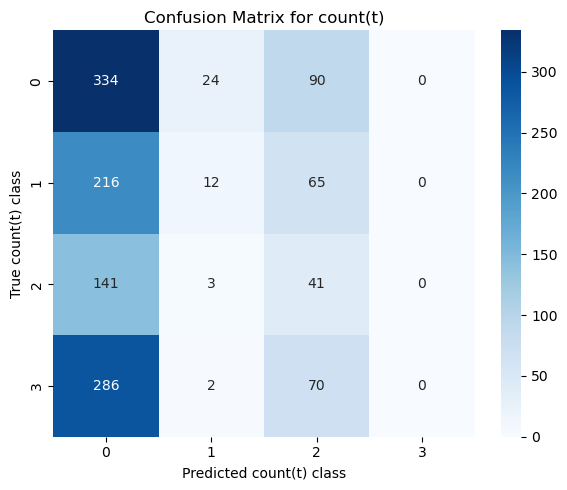

Reply Classification Report:
              precision    recall  f1-score   support

         0.0     0.4597    0.3058    0.3673       448
         1.0     0.6846    0.8074    0.7409       836

    accuracy                         0.6324      1284
   macro avg     0.5722    0.5566    0.5541      1284
weighted avg     0.6061    0.6324    0.6106      1284



In [10]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Ensure model is in evaluation mode and loaded
model = BehavioralPointProcessModel(input_dim=X_val.shape[2])
model.load_state_dict(torch.load("best_multitask_model.pt"))
model.eval()

# Prepare predictions
with torch.no_grad():
    m_val = (X_val.sum(dim=-1) != 0)
    output = model(X_val, t_val, m_val)

    pred_reply = (output['reply_prob'] > 0.5).float()
    pred_lambda = torch.expm1(output['lambda'])  # convert back from log1p
    pred_count = torch.argmax(output['count_logits'], dim=-1)

    true_reply = y_val
    true_lambda = torch.expm1(lambda_val)
    true_count = count_val_class

# Apply mask to keep only valid time steps
mask = (X_val.sum(dim=-1) != 0)

flat_pred_reply = pred_reply[mask].cpu().numpy()
flat_true_reply = true_reply[mask].cpu().numpy()

flat_pred_lambda = pred_lambda[mask].cpu().numpy()
flat_true_lambda = true_lambda[mask].cpu().numpy()

flat_pred_count = pred_count[mask].cpu().numpy()
flat_true_count = true_count[mask].cpu().numpy()

# === λ(t) Error Histogram ===
lambda_errors = abs(flat_true_lambda - flat_pred_lambda)
plt.figure(figsize=(8, 4))
plt.hist(lambda_errors, bins=50, color='skyblue', edgecolor='black')
plt.title("Histogram of λ(t) Absolute Errors (in hours)")
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Confusion Matrix for count(t) ===
cm = confusion_matrix(flat_true_count, flat_pred_count)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2,3], yticklabels=[0,1,2,3])
plt.xlabel("Predicted count(t) class")
plt.ylabel("True count(t) class")
plt.title("Confusion Matrix for count(t)")
plt.tight_layout()
plt.show()

# === Precision / Recall / F1 for reply classification ===
print("Reply Classification Report:")
print(classification_report(flat_true_reply, flat_pred_reply, digits=4))
